# Task 3 - Pool Ball Detection

The objective of this task is to detect every pool ball present on the table and classify it into one of the following classes:

- Black
- Cue
- Solid
- Striped

Three state-of-the-art object detection architectures are evaluated:

- YOLOv8n
- YOLOv8s
- RT-DETR

The models are compared using Precision, Recall, mAP@50 and mAP@50-95. Finally, qualitative comparisons are performed by visualizing the predictions produced by each detector.

## Imports

In [5]:
%matplotlib inline
import os
import json
import random
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from PIL import Image
from tqdm.notebook import tqdm
from ultralytics import YOLO, RTDETR

## Configurations

In [21]:
DATASET_ROOT = Path("datasets-yolo/main_dataset/8-Ball-Pool-3")

NEW_DIR = Path("new_detection_dataset")
RUNS_DIR = Path("runs")
OUTPUT_DIR = Path("outputs")
MODELS_DIR = Path("models")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# folders
for p in [
    NEW_DIR,
    RUNS_DIR,
    OUTPUT_DIR,
    MODELS_DIR,
    OUTPUT_DIR / "metrics",
]:
    p.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["Black", "Cue", "Solid", "Striped"]

Device: cuda


## Dataset Overview

The experiments use the 8-Ball-Pool dataset.

The original dataset contains five classes:

- Black
- Cue
- Dot
- Solid
- Striped

Total images: 247


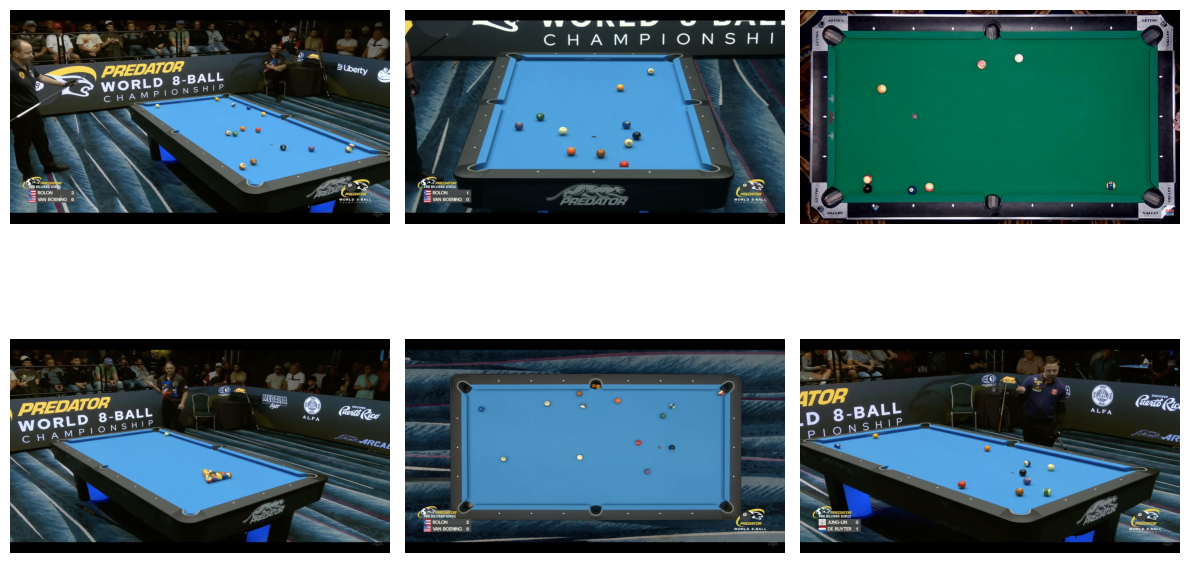

In [22]:
def collect_main_pairs(dataset_root):
    images_dir = dataset_root / "train" / "images"
    labels_dir = dataset_root / "train" / "labels"

    pairs = []

    for img_path in images_dir.glob("*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            continue

        label_path = labels_dir / f"{img_path.stem}.txt"

        if label_path.exists():
            pairs.append((img_path, label_path))

    return pairs

pairs = collect_main_pairs(DATASET_ROOT)

print(f"Total images: {len(pairs)}")

fig, ax = plt.subplots(2,3, figsize=(12,8))

for axis, (img_path, _) in zip(ax.ravel(), random.sample(pairs,6)):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axis.imshow(img)
    axis.axis("off")

plt.tight_layout()

## Dataset Preparation

The following preprocessing steps were applied:

1. Split the dataset into training, validation and testing subsets.
2. Remove the Dot class from the annotations.
3. Remap the remaining class identifiers.
4. Generate the final YOLO dataset.

In [23]:
def split_pairs(pairs, ratios=(0.8, 0.1, 0.1), seed=42):
    rng = random.Random(seed)
    pairs = pairs.copy()
    rng.shuffle(pairs)

    n = len(pairs)
    n_train = int(n * ratios[0])
    n_valid = int(n * ratios[1])

    train = pairs[:n_train]
    valid = pairs[n_train:n_train + n_valid]
    test = pairs[n_train + n_valid:]

    return train, valid, test

train_pairs, valid_pairs, test_pairs = split_pairs(
    pairs,
    ratios=(0.8, 0.1, 0.1),
    seed=SEED
)

print("Total pairs:", len(pairs))
print("Train:", len(train_pairs))
print("Valid:", len(valid_pairs))
print("Test:", len(test_pairs))

Total pairs: 247
Train: 197
Valid: 24
Test: 26


In [24]:
def copy_split(pairs, split):
    img_out = NEW_DIR / split / "images"
    lbl_out = NEW_DIR / split / "labels"

    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    for i, (img_path, label_path) in enumerate(pairs):
        
        shutil.copy(img_path, img_out / f"{img_path.stem}{img_path.suffix.lower()}")
        shutil.copy(label_path, lbl_out / f"{img_path.stem}.txt")


def remove_dot_and_remap_labels(dataset_dir):
    """
    Original classes:
    0 Black
    1 Cue
    2 Dot      -> removed
    3 Solid    -> 2
    4 Striped  -> 3

    Final classes:
    0 Black
    1 Cue
    2 Solid
    3 Striped
    """

    label_files = list(dataset_dir.glob("**/labels/*.txt"))

    class_map = {
        0: 0,
        1: 1,
        3: 2,
        4: 3,
    }

    removed = 0
    kept = 0

    for label_file in label_files:
        new_lines = []

        with open(label_file, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            old_cls = int(parts[0])

            if old_cls == 2:
                removed += 1
                continue

            if old_cls not in class_map:
                continue

            parts[0] = str(class_map[old_cls])
            new_lines.append(" ".join(parts))
            kept += 1

        with open(label_file, "w") as f:
            f.write("\n".join(new_lines))

    print(f"Kept labels: {kept}")
    print(f"Removed Dot labels: {removed}")


# clean merged dataset
if NEW_DIR.exists():
    shutil.rmtree(NEW_DIR)

copy_split(train_pairs, "train")
copy_split(valid_pairs, "valid")
copy_split(test_pairs, "test")

remove_dot_and_remap_labels(NEW_DIR)


for split in ["train", "valid", "test"]:
    n_img = len(list((NEW_DIR / split / "images").glob("*")))
    n_lbl = len(list((NEW_DIR / split / "labels").glob("*")))
    print(split, n_img, n_lbl)

    if n_img == 0 or n_lbl == 0:
        raise ValueError(f"{split} split is empty")

Kept labels: 2817
Removed Dot labels: 4426
train 197 197
valid 24 24
test 26 26


## Annotation Transformation

The original annotations contain five classes.

Since the Dot class does not correspond to a pool ball, these annotations are removed and the remaining labels are remapped to consecutive class identifiers.

In [25]:
yaml_text = f"""
path: {NEW_DIR.resolve()}
train: train/images
val: valid/images
test: test/images

names:
  0: Black
  1: Cue
  2: Solid
  3: Striped
"""

yaml_path = NEW_DIR / "data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_text)

print(yaml_path.read_text())


path: /home/admin/Documents/FEUP-CV/proj/task3/new_detection_dataset
train: train/images
val: valid/images
test: test/images

names:
  0: Black
  1: Cue
  2: Solid
  3: Striped



## Training

Three object detection architectures are evaluated.

**YOLOv8n** - Lightweight CNN detector.

**YOLOv8s** - Larger CNN detector.

**RT-DETR** - Transformer-based detector optimized for real-time object detection.

In [ ]:
# TRAIN YOLOv8n

yolo_n = YOLO("yolov8n.pt")

results_n = yolo_n.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    workers=0,
    cache=False,
    amp=True,
    project=str(RUNS_DIR.resolve()),
    name="yolov8n",
    exist_ok=True,
    patience=10,
    device=0 if DEVICE == "cuda" else "cpu"
)

In [ ]:
# TRAIN YOLOv8s

yolo_s = YOLO("yolov8s.pt")

results_s = yolo_s.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    workers=0,
    cache=False,
    amp=True,
    project=str(RUNS_DIR.resolve()),
    name="yolov8s",
    exist_ok=True,
    patience=10,
    device=0 if DEVICE == "cuda" else "cpu"
)

In [ ]:
# TRAIN RT-DETR

detr = RTDETR("rtdetr-l.pt")

results_detr = detr.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=4,
    workers=0,
    cache=False,
    amp=True,
    project=str(RUNS_DIR.resolve()),
    name="rtdetr",
    exist_ok=True,
    patience=10,
    device=0 if DEVICE == "cuda" else "cpu"
)

## Quantitative Evaluation

The trained detectors are evaluated on the test split using four standard object detection metrics:

- **Precision**: proportion of predicted detections that are correct.
- **Recall**: proportion of ground-truth objects that were detected.
- **mAP@50**: mean Average Precision using IoU threshold 0.50.
- **mAP@50-95**: stricter COCO-style metric averaged over IoU thresholds from 0.50 to 0.95.

The evaluated models are YOLOv8n, YOLOv8s and RT-DETR.

In [26]:
model_paths = {
    "YOLOv8n": RUNS_DIR / "yolov8n" / "weights" / "best.pt",
    "YOLOv8s": RUNS_DIR / "yolov8s" / "weights" / "best.pt",
    "RT-DETR": RUNS_DIR / "rtdetr" / "weights" / "best.pt",
}

def load_model(model_name, model_path):
    if model_name == "RT-DETR":
        return RTDETR(str(model_path))
    return YOLO(str(model_path))

eval_results = []
per_class_results = {}

for model_name, model_path in model_paths.items():
    print(f"Evaluating {model_name}")

    model = load_model(model_name, model_path)

    metrics = model.val(
        data=str(yaml_path),
        split="test",
        imgsz=640,
        batch=1,
        workers=0,
        device=0 if DEVICE == "cuda" else "cpu"
    )

    eval_results.append({
        "Model": model_name,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr,
    })

    per_class_results[model_name] = pd.DataFrame({
        "Class": CLASS_NAMES,
        "AP50-95": metrics.box.maps
    })

results_df = pd.DataFrame(eval_results)
results_df.to_csv(OUTPUT_DIR / "metrics" / "detection_results.csv", index=False)

results_df

Evaluating YOLOv8n
Ultralytics 8.4.67 🚀 Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (Quadro RTX 8000, 48395MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1764.9±528.6 MB/s, size: 117.0 KB)
val: Scanning /home/admin/Documents/FEUP-CV/proj/task3/new_detection_dataset/test/labels... 26 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 26/26 1.0Kit/s 0.0s
val: New cache created: /home/admin/Documents/FEUP-CV/proj/task3/new_detection_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 7.3it/s 3.5s0.1s
                   all         26        291      0.928      0.841      0.922      0.757
                 Black         25         25      0.956      0.871      0.909      0.753
                   Cue         26         26          1      0.794      0.967      0.819
                 Solid         25        127      0.884   

,Model,mAP50,mAP50-95,Precision,Recall
0,YOLOv8n,0.922017,0.757445,0.928264,0.841213
1,YOLOv8s,0.936305,0.786659,0.968335,0.893190
2,RT-DETR,0.965882,0.835638,0.979068,0.938766


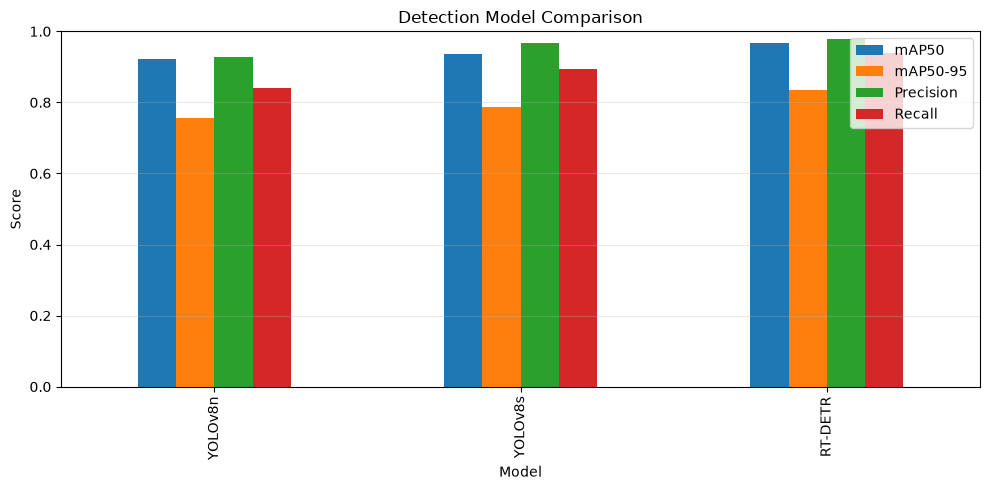

In [27]:
ax = results_df.plot(
    x="Model",
    kind="bar",
    figsize=(10, 5),
    title="Detection Model Comparison"
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "metrics" / "model_comparison.png",
    bbox_inches="tight"
)

plt.show()


RT-DETR achieved the best overall performance among the evaluated models, obtaining the highest Precision, Recall, mAP@50 and mAP@50-95. YOLOv8s also improved over YOLOv8n, showing that increasing model capacity improved detection performance.

## Per-Class Performance

To better understand the behaviour of each model, the AP@50-95 metric is also analysed per class.

This allows us to verify whether the detector performs equally well for all ball categories or whether some classes are more difficult.

In [28]:
for model_name, df_class in per_class_results.items():
    print(model_name)
    display(df_class)

    df_class.to_csv(
        OUTPUT_DIR / model_name / "per_class_metrics.csv",
        index=False
    )

YOLOv8n


,Class,AP50-95
0,Black,0.753451
1,Cue,0.818980
2,Solid,0.757341
3,Striped,0.700007


YOLOv8s


,Class,AP50-95
0,Black,0.744498
1,Cue,0.847351
2,Solid,0.799812
3,Striped,0.754976


RT-DETR


,Class,AP50-95
0,Black,0.793782
1,Cue,0.885326
2,Solid,0.851173
3,Striped,0.812272


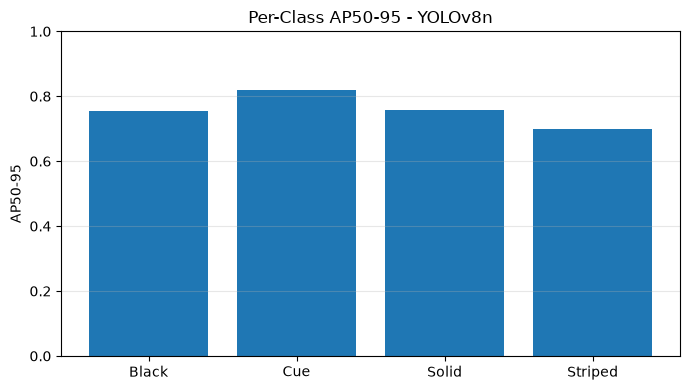

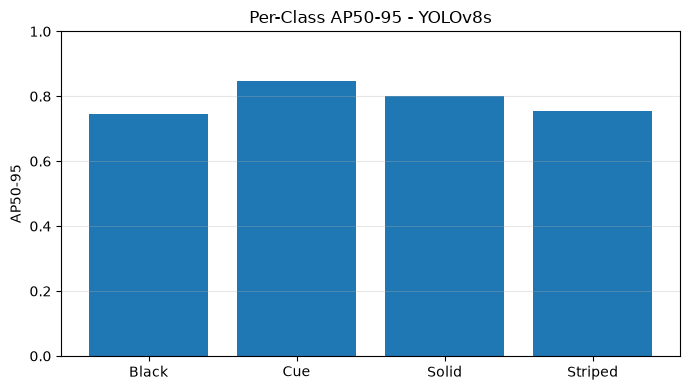

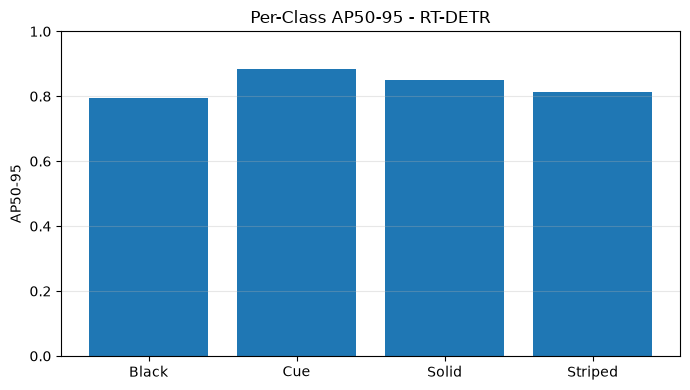

In [29]:
for model_name, df_class in per_class_results.items():
    plt.figure(figsize=(7, 4))

    plt.bar(
        df_class["Class"],
        df_class["AP50-95"]
    )

    plt.title(f"Per-Class AP50-95 - {model_name}")
    plt.ylabel("AP50-95")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    model_dir = OUTPUT_DIR / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        model_dir / "per_class_ap.png",
        bbox_inches="tight"
    )

    plt.show()

The per-class results help identify which ball categories are easier or harder to detect. In general, the Cue and Black classes are expected to be easier because they have distinctive visual appearances, while Solid and Striped balls may be more challenging due to visual similarity, occlusion or overlapping balls.

## Qualitative Results

Quantitative metrics provide an overall comparison, but visual inspection is also important for object detection.

The following examples compare YOLOv8n, YOLOv8s and RT-DETR on the same test images. This allows us to observe differences in missed detections, false positives and bounding-box quality.

In [30]:
test_images = list((NEW_DIR / "test" / "images").glob("*"))

sample_images = random.sample(
    test_images,
    min(5, len(test_images))
)

comparison_dir = OUTPUT_DIR / "comparison_examples"
comparison_dir.mkdir(parents=True, exist_ok=True)

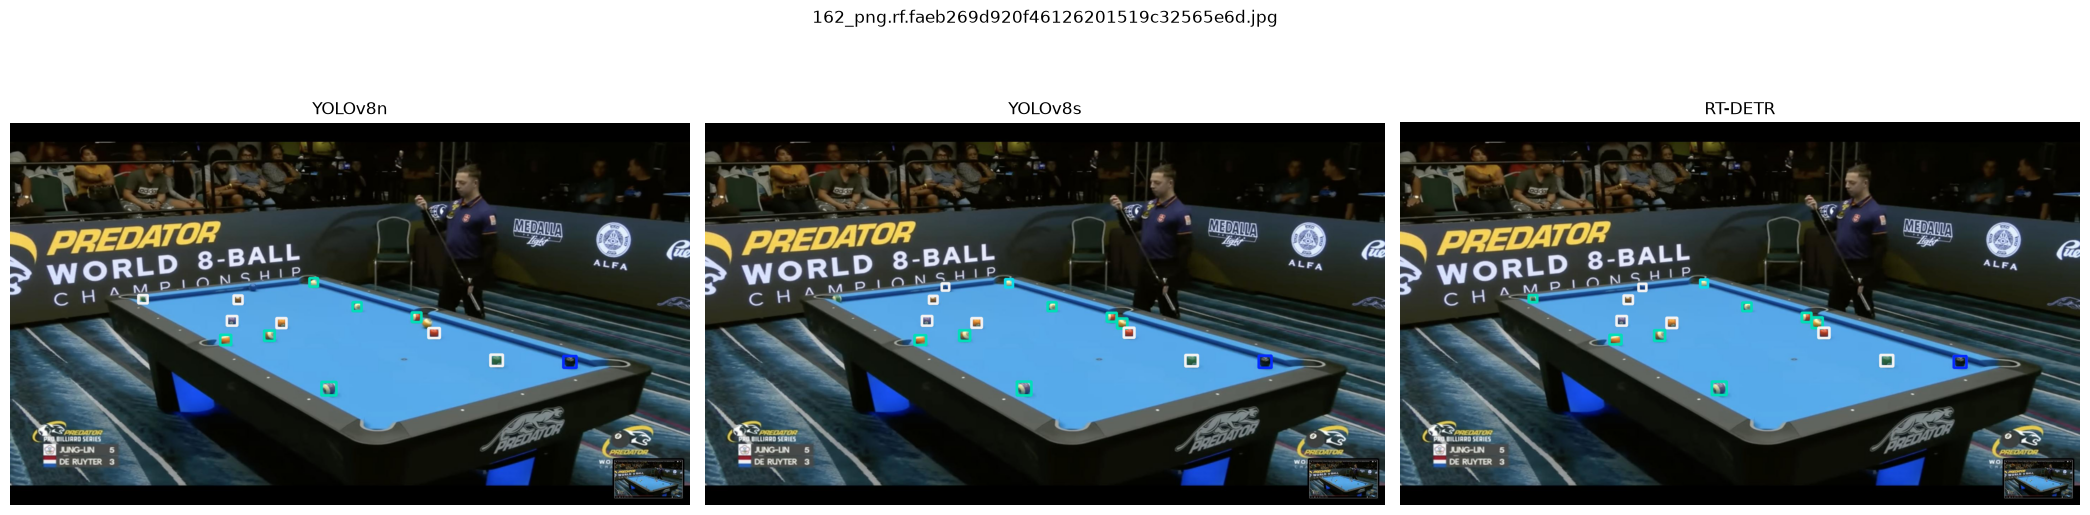

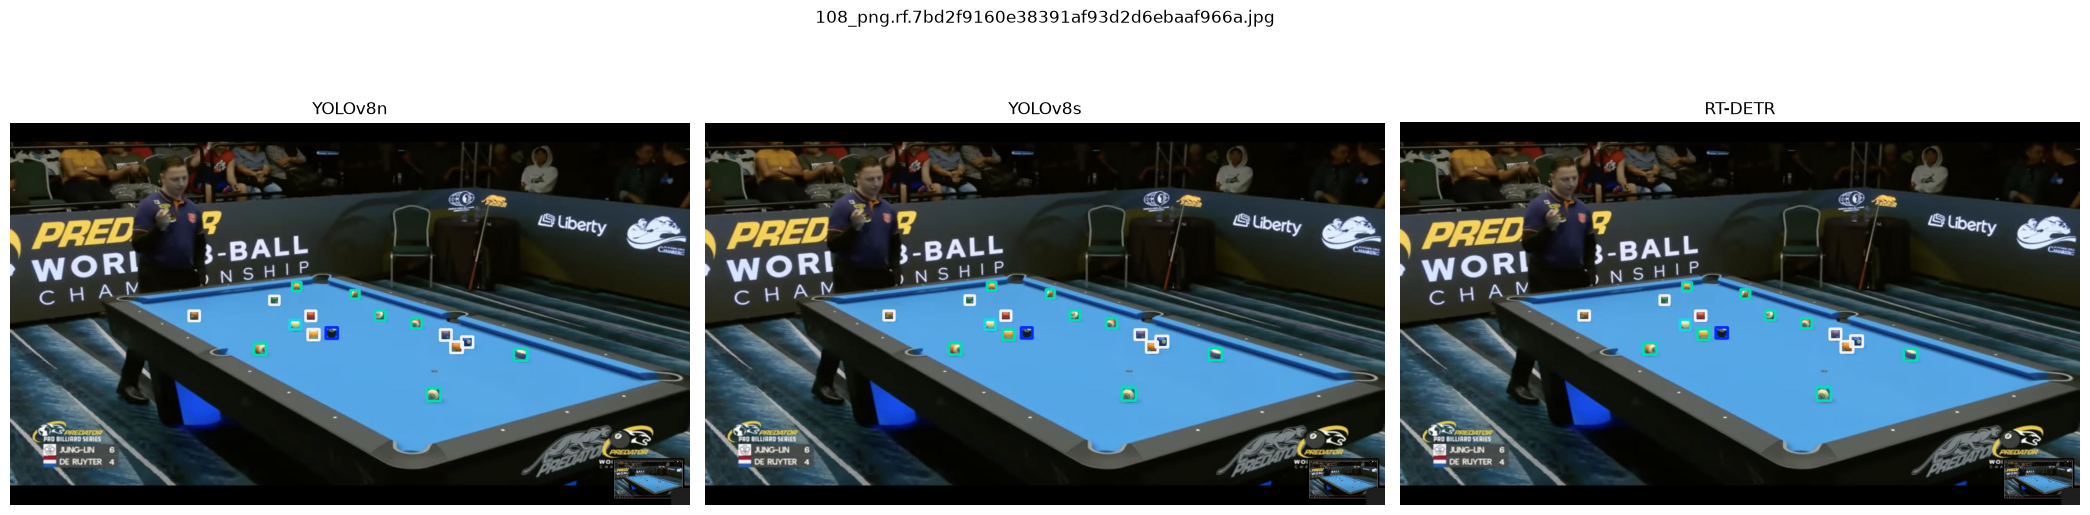

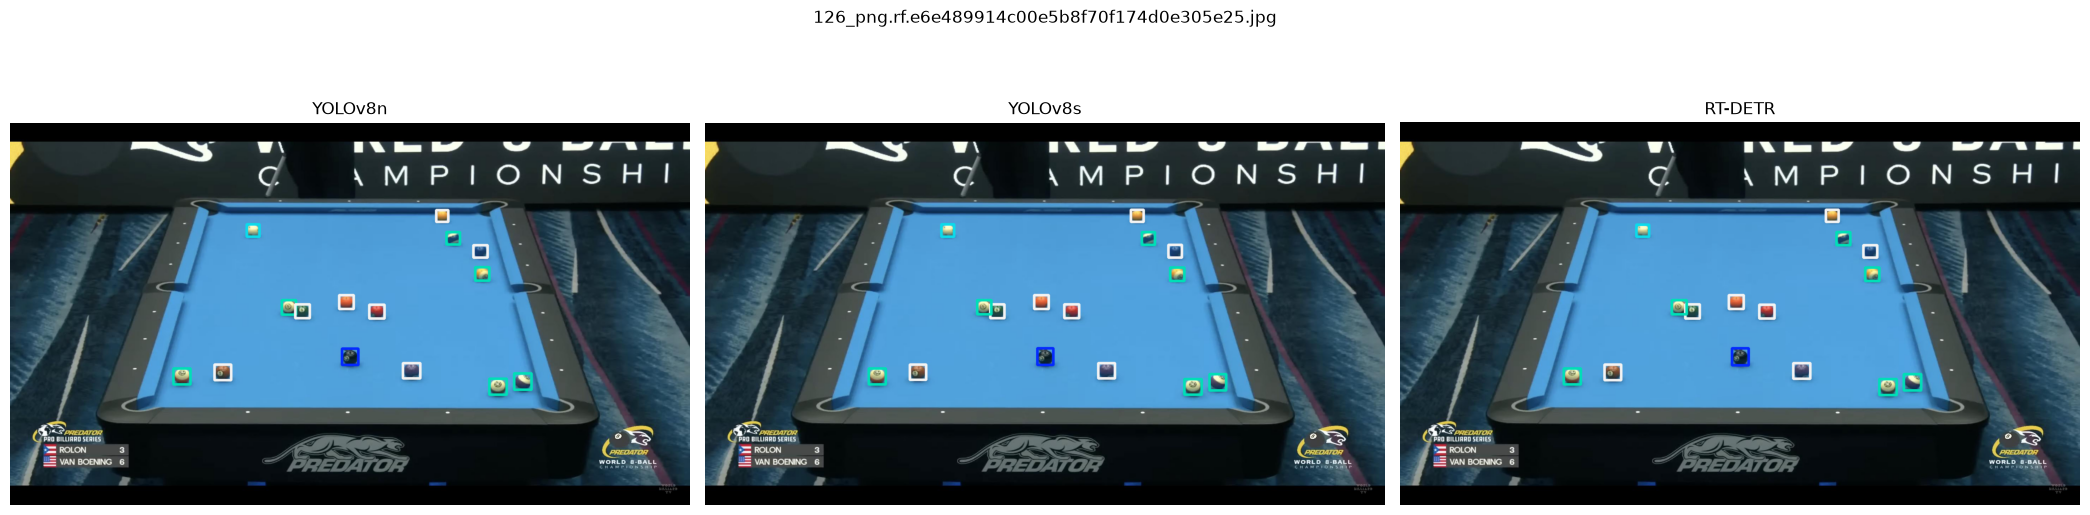

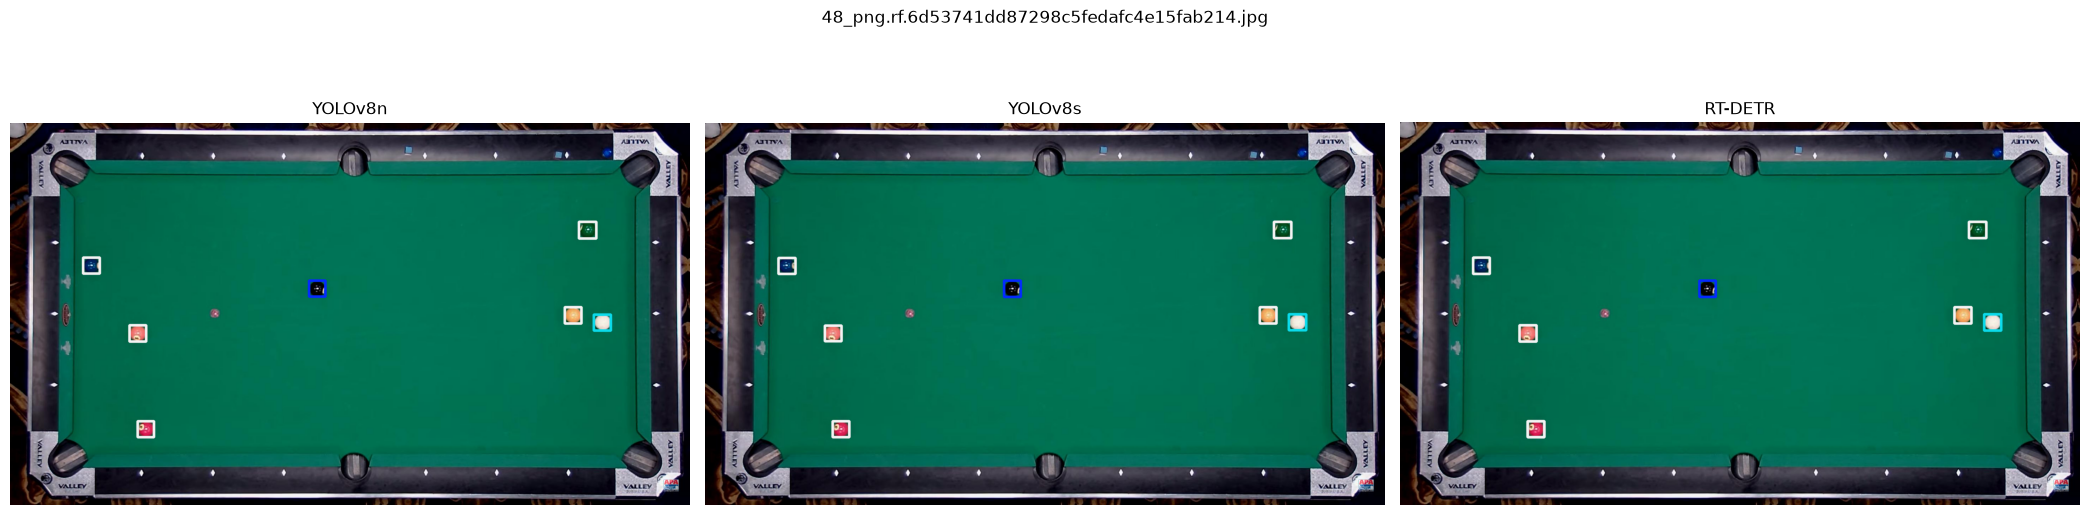

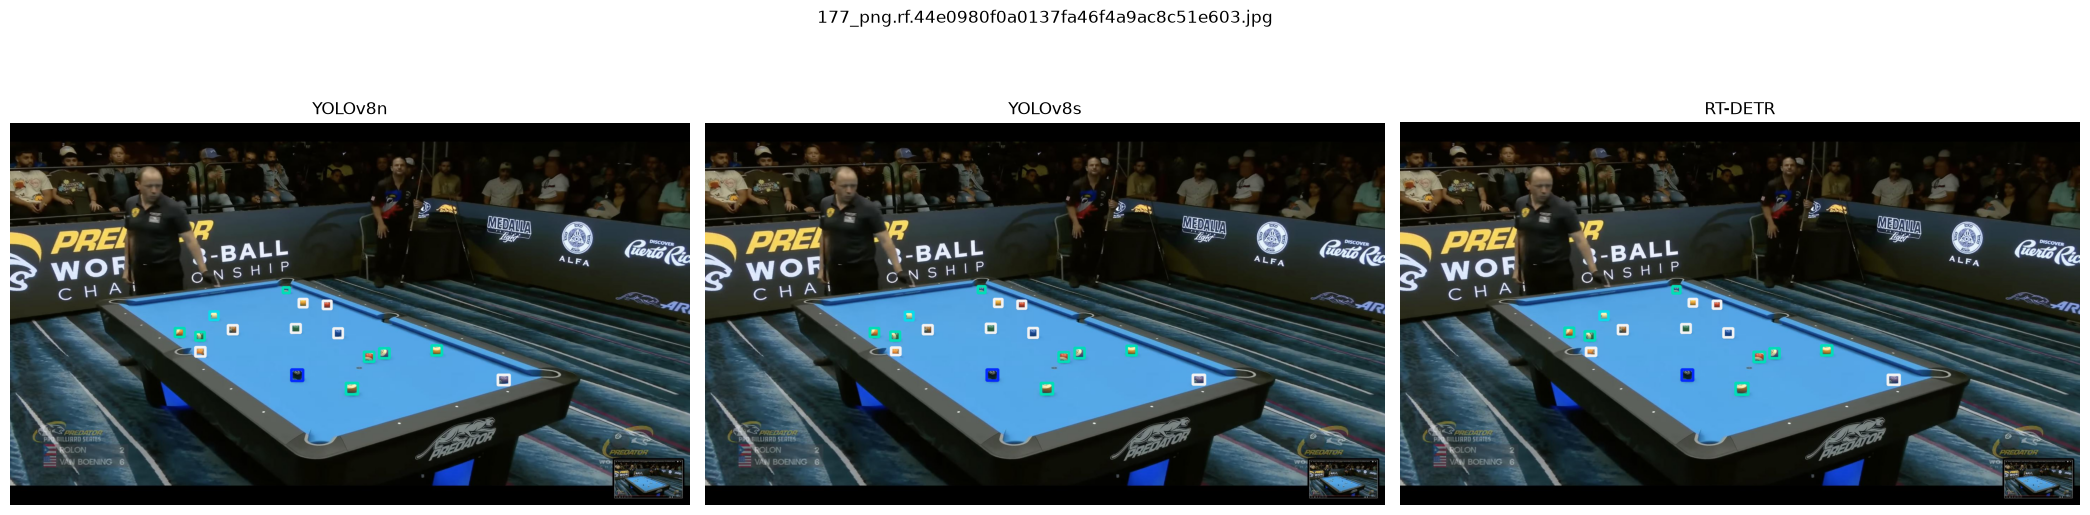

In [31]:
for img_path in sample_images:
    n_models = len(model_paths)

    plt.figure(figsize=(7 * n_models, 6))

    for idx, (model_name, model_path) in enumerate(model_paths.items()):
        model = load_model(model_name, model_path)

        results = model.predict(
            source=str(img_path),
            conf=0.25,
            imgsz=640,
            save=False,
            verbose=False
        )

        plotted = results[0].plot(
            labels=False,
            conf=False
        )
        plt.subplot(1, n_models, idx + 1)
        plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
        plt.title(model_name)
        plt.axis("off")

    plt.suptitle(img_path.name)
    plt.tight_layout()

    plt.savefig(
        comparison_dir / f"{img_path.stem}_comparison.png",
        bbox_inches="tight"
    )

    plt.show()

**Legend**: 
- Black : Blue 
- Cue : Light blue 
- Solid : White
- Striped : Green

The visual comparison shows how the different architectures behave on the same examples. In particular, these figures are useful to identify missed balls, incorrect class predictions and differences in bounding-box localization.

## Prediction Output

Although a JSON file is not required for Task 3 submission, predictions were exported to JSON to make the results easier to inspect and reuse.

Each detection contains:

- image name;
- predicted class;
- confidence score;
- bounding box coordinates;
- normalized center position.

In [32]:
def export_predictions_to_json(model, image_paths, output_json, conf=0.25):
    all_predictions = []

    for img_path in tqdm(image_paths):
        results = model.predict(
            source=str(img_path),
            conf=conf,
            imgsz=640,
            save=False,
            verbose=False
        )

        r = results[0]

        image_data = {
            "image": str(img_path),
            "image_name": img_path.name,
            "detections": []
        }

        if r.boxes is not None:
            boxes_xyxy = r.boxes.xyxy.cpu().numpy()
            boxes_xywh = r.boxes.xywh.cpu().numpy()
            classes = r.boxes.cls.cpu().numpy()
            confs = r.boxes.conf.cpu().numpy()

            h, w = r.orig_shape

            for box_xyxy, box_xywh, cls_id, score in zip(
                boxes_xyxy,
                boxes_xywh,
                classes,
                confs
            ):
                cls_id = int(cls_id)

                x1, y1, x2, y2 = box_xyxy.tolist()
                cx, cy, bw, bh = box_xywh.tolist()

                image_data["detections"].append({
                    "class_id": cls_id,
                    "class_name": model.names[cls_id],
                    "confidence": float(score),

                    "bbox_xyxy": {
                        "x1": float(x1),
                        "y1": float(y1),
                        "x2": float(x2),
                        "y2": float(y2),
                    },

                    "bbox_xywh": {
                        "x_center": float(cx),
                        "y_center": float(cy),
                        "width": float(bw),
                        "height": float(bh),
                    },

                    "normalized_position": {
                        "x_center": float(cx / w),
                        "y_center": float(cy / h),
                        "width": float(bw / w),
                        "height": float(bh / h),
                    }
                })

        all_predictions.append(image_data)

    with open(output_json, "w") as f:
        json.dump(all_predictions, f, indent=4)

    print(f"Saved predictions to {output_json}")

In [33]:
for model_name, model_path in model_paths.items():
    model = load_model(model_name, model_path)

    pred_dir = OUTPUT_DIR / model_name / "predictions"
    pred_dir.mkdir(parents=True, exist_ok=True)

    export_predictions_to_json(
        model=model,
        image_paths=test_images,
        output_json=pred_dir / "test_predictions.json",
        conf=0.25
    )

  0%|          | 0/26 [00:00<?, ?it/s]

Saved predictions to outputs/YOLOv8n/predictions/test_predictions.json


  0%|          | 0/26 [00:00<?, ?it/s]

Saved predictions to outputs/YOLOv8s/predictions/test_predictions.json


  0%|          | 0/26 [00:00<?, ?it/s]

Saved predictions to outputs/RT-DETR/predictions/test_predictions.json


## Conclusions 

Among the evaluated architectures, RT-DETR achieved the best overall detection performance.

Compared with YOLOv8n and YOLOv8s, it obtained the highest Precision, Recall and mAP values, while also producing more accurate detections in challenging scenarios.

Consequently, RT-DETR was selected as the detector used in the following retrieval stage.

# Task 3 - Similar Games


In [34]:
from roboflow import Roboflow
from pathlib import Path
from ultralytics import YOLO
import os
import shutil
import cv2
import numpy as np

In [64]:
# Paths
DATASET_PATH = Path(".")
CURRENT_DIR = Path.cwd()

MODEL_PATH = "pool_table_seg_best.pt"
TRAIN_DATA_YAML = "billiard-9/data.yaml"
TARGET_IMAGES = "../datasets/main_dataset/data/train"

MID_DIR = Path("./results2")
OUTPUT_DIR = MID_DIR / "run1"
KEYPOINT_DIR = MID_DIR / "keypoints"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
KEYPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Flags
LOAD_DATA = False
TRAIN = False
TEST = True

In [71]:
model = load_model("RT-DETR", RUNS_DIR / "rtdetr" / "weights" / "best.pt")

export_predictions_to_json(
    model=model,
    image_paths=list((Path(TARGET_IMAGES)).glob("*.jpg")),
    output_json="global_detections.json",
    conf=0.25
)

  0%|          | 0/247 [00:00<?, ?it/s]

Saved predictions to global_detections.json


## Dataset Download

In [ ]:
def download_latest_roboflow_dataset():
    os.chdir(DATASET_PATH)

    rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))

    workspace_name = "arena-qye1f"
    project_name = "billiard-7sno1"

    project = rf.workspace(workspace_name).project(project_name)
    versions = project.versions()

    latest_version = max(versions, key=lambda v: int(v.version))

    print(f"Downloading version {latest_version.version}...")
    latest_version.download("yolov8")

    os.chdir(CURRENT_DIR)


if LOAD_DATA:
    download_latest_roboflow_dataset()  

## Train YOLO Segmentation Model

In [ ]:
def train_segmentation_model():
    model = YOLO("yolov8n-seg.pt")

    results = model.train(
        data=TRAIN_DATA_YAML,
        epochs=50,
        imgsz=640,
        batch=16,
        device="0",
        workers=0,
        name="pool_table_seg_model",
        project="runs/seg",
        exist_ok=True,
    )

    best_model_path = results.save_dir / "weights" / "best.pt"

    shutil.copy(best_model_path, MODEL_PATH)

    print(f"Best model saved at: {best_model_path}")
    print(f"Copied final model to: {MODEL_PATH}")

    return best_model_path


if TRAIN:
    best_model_path = train_segmentation_model()

In [ ]:
def validate_model(model_path):
    metrics = YOLO(model_path).val(
        data=TRAIN_DATA_YAML,
        device="0",
        batch=8,
        workers=0,
    )

    print(f"Box mAP50: {metrics.box.map50:.4f}")
    print(f"Box mAP50-95: {metrics.box.map:.4f}")
    print(f"Seg mAP50: {metrics.seg.map50:.4f}")
    print(f"Seg mAP50-95: {metrics.seg.map:.4f}")


if TRAIN:
    validate_model(MODEL_PATH)

In [72]:
model = YOLO(MODEL_PATH)

## Corner Extraction Functions

In [73]:
def get_corners_from_polygon(polygon):
    polygon = polygon.astype(np.float32)

    hull = cv2.convexHull(polygon)

    epsilon = 0.02 * cv2.arcLength(hull, True)
    approx = cv2.approxPolyDP(hull, epsilon, True)

    if len(approx) != 4:
        rect = cv2.minAreaRect(hull)
        box = cv2.boxPoints(rect)
        return box.astype(np.float32)

    return approx.reshape(4, 2).astype(np.float32)


def order_corners_long_side_horizontal(points):
    pts = np.array(points, dtype=np.float32)

    hull = cv2.convexHull(pts).reshape(-1, 2)

    if len(hull) != 4:
        rect = cv2.minAreaRect(pts)
        hull = cv2.boxPoints(rect).astype(np.float32)

    center = hull.mean(axis=0)

    angles = np.arctan2(
        hull[:, 1] - center[1],
        hull[:, 0] - center[0]
    )

    ordered = hull[np.argsort(angles)]

    edges = []
    for i in range(4):
        p1 = ordered[i]
        p2 = ordered[(i + 1) % 4]
        edges.append(np.linalg.norm(p2 - p1))

    long_edge_idx = int(np.argmax(edges))
    ordered = np.roll(ordered, -long_edge_idx, axis=0)

    if ordered[0][1] > ordered[2][1]:
        ordered = np.roll(ordered, 2, axis=0)

    left_two = ordered[np.argsort(ordered[:, 0])[:2]]
    right_two = ordered[np.argsort(ordered[:, 0])[2:]]

    tl = left_two[np.argmin(left_two[:, 1])]
    bl = left_two[np.argmax(left_two[:, 1])]
    tr = right_two[np.argmin(right_two[:, 1])]
    br = right_two[np.argmax(right_two[:, 1])]

    return np.array([tl, tr, br, bl], dtype=np.float32)

## Homography Function

In [74]:
def homography(img, kpts, out_w=800, out_h=400):
    src_pts = order_corners_long_side_horizontal(kpts)

    dst_pts = np.array([
        [0, 0],
        [out_w - 1, 0],
        [out_w - 1, out_h - 1],
        [0, out_h - 1],
    ], dtype=np.float32)

    H = cv2.getPerspectiveTransform(src_pts, dst_pts)

    warped_img = cv2.warpPerspective(
        img,
        H,
        (out_w, out_h)
    )

    return warped_img, H

## Load Ball Detection JSON

In [ ]:
import json

DETECTIONS_JSON = "global_detections.json"

with open(DETECTIONS_JSON, "r") as f:
    ball_data = json.load(f)

ball_data_by_name = {
    item["image_name"]: item
    for item in ball_data
}

print(ball_data_by_name.keys())

dict_keys(['0_png.rf.e35063c144cfd241454863d624cf01d3.jpg', '171_png.rf.e0f78688a6d730302708d2eec60a4bdf.jpg', '9t_png.rf.9fed287c2c696d2899ea436ef7e3d20d.jpg', '115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg', '25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg', '161_png.rf.2436f2b0f85b3351121e334fce1ae80c.jpg', '38_png.rf.5f7178d32f8c80830acba72ceaa53c52.jpg', '40_png.rf.5bb1a2e7946b7a35cb9e87950cc508da.jpg', '167_png.rf.9c4562ed01369906a44a489f10bd858b.jpg', '160_png.rf.6f41e2456edd6888c9fae22813acc55e.jpg', '165_png.rf.24adc446423ba35cdbff16ccaffc9785.jpg', '8_png.rf.00b44beea89152bdea072ac458c5ec85.jpg', '63_png.rf.f5b4c1c38fa5fd80098db299a9f5f331.jpg', '21_png.rf.14a3f0eb3df1717c54de3445f3988524.jpg', '137_png.rf.bbe9edbb99cbe83b2d718df3122d9344.jpg', '17a_png.rf.156d5bf7e3400bc2a30f1251bb4dd348.jpg', '123_png.rf.c77820fd3abbca5d6265af63564f9564.jpg', '56_png.rf.d816086571a6166985bd89660706de3c.jpg', '103_png.rf.8837c4ba6e91c59a634fc8cd30cd204b.jpg', '13t_png.rf.6106fd96f4902de298

## Transform Ball Positions Using Homography


In [76]:
def transform_point_with_H(x, y, H, out_w=800, out_h=400):
    point = np.array([[[x, y]]], dtype=np.float32)

    transformed = cv2.perspectiveTransform(point, H)[0][0]

    x_warped, y_warped = transformed

    return {
        "x": float(x_warped),
        "y": float(y_warped),
        "x_norm": float(x_warped / out_w),
        "y_norm": float(y_warped / out_h),
    }


def get_warped_balls_for_image(image_name, H, out_w=800, out_h=400):
    item = ball_data_by_name.get(image_name)

    if item is None:
        print(f"No detections in JSON for {image_name}")
        return []

    warped_balls = []

    for det in item["detections"]:
        pos = det["bbox_xywh"]

        x = pos["x_center"]
        y = pos["y_center"]

        warped_pos = transform_point_with_H(x, y, H, out_w, out_h)

        warped_balls.append({
            "class_id": det["class_id"],
            "class_name": det["class_name"],
            "confidence": det["confidence"],
            "x": warped_pos["x"],
            "y": warped_pos["y"],
            "x_norm": warped_pos["x_norm"],
            "y_norm": warped_pos["y_norm"],
        })

    return warped_balls

## Visualization Helpers

In [77]:
def draw_keypoints(img, kpts):
    vis = img.copy()

    for i, (x, y) in enumerate(kpts):
        x, y = int(x), int(y)

        cv2.circle(vis, (x, y), 8, (0, 0, 255), -1)

        cv2.putText(
            vis,
            str(i),
            (x + 10, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2,
        )

    return vis

## Process One Image

In [84]:
def process_image(img_path, model, conf=0.10):
    img = cv2.imread(str(img_path))

    results = model.predict(
        str(img_path),
        conf=conf,
        verbose=False,
        save=True,
        project=str(MID_DIR.absolute()),
        name="mid",
        exist_ok=True,
    )

    result = results[0]

    if result.masks is None:
        print(f"No table detected: {img_path.name}")
        return None

    polygon = result.masks.xy[0]
    kpts = get_corners_from_polygon(polygon)

    seg_img = result.plot()
    seg_keypoints_img = draw_keypoints(seg_img, kpts)


    #cv2.imwrite(
    #    os.path.join(KEYPOINT_DIR, f"seg_keypoints_{img_path.name}"),
    #    seg_keypoints_img
    #)

    save_img, H = homography(img, kpts)

    #cv2.imwrite(
    #    os.path.join(OUTPUT_DIR, f"homography_{img_path.name}"),
    #    save_img
    #)


    warped_img, H = homography(img, kpts)

    warped_balls = get_warped_balls_for_image(
        img_path.name,
        H,
        out_w=800,
        out_h=400
    )

    return {
        "image_name": img_path.name,
        "original": img,
        "segmentation": seg_img,
        "keypoints": seg_keypoints_img,
        "warped": warped_img,
        "H": H,
        "kpts": kpts,
        "balls": warped_balls,
    }

## Process Full Dataset

In [85]:
def build_table_state_database(target_images, model):
    target_images = Path(target_images)

    table_states = {}

    for img_path in sorted(target_images.iterdir()):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        output = process_image(img_path, model)

        if output is None:
            continue

        table_states[img_path.name] = {
            "image_name": img_path.name,
            "image_path": str(img_path),
            "balls": output["balls"],
            "H": output["H"],
        }

    return table_states


table_states = build_table_state_database(TARGET_IMAGES, model)

Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid


Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Results saved to /home/admin/Documents/FEUP-CV/proj/task3/results2/mid
Result

## Similarity Between Two Tables

In [ ]:

from collections import Counter
from scipy.optimize import linear_sum_assignment

def count_similarity(balls_a, balls_b):
    count_a = Counter([b["class_name"] for b in balls_a])
    count_b = Counter([b["class_name"] for b in balls_b])

    all_classes = set(count_a.keys()) | set(count_b.keys())

    difference = 0

    for cls in all_classes:
        difference += abs(count_a[cls] - count_b[cls])

    return difference


def position_distance_for_class(balls_a, balls_b, class_name):
    a = [b for b in balls_a if b["class_name"] == class_name]
    b = [b for b in balls_b if b["class_name"] == class_name]

    if len(a) == 0 or len(b) == 0:
        return max(len(a), len(b))

    cost = np.zeros((len(a), len(b)))

    for i, ball_a in enumerate(a):
        for j, ball_b in enumerate(b):
            dx = ball_a["x_norm"] - ball_b["x_norm"]
            dy = ball_a["y_norm"] - ball_b["y_norm"]
            cost[i, j] = np.sqrt(dx ** 2 + dy ** 2)

    row_ind, col_ind = linear_sum_assignment(cost)

    matched_cost = cost[row_ind, col_ind].sum()

    unmatched = abs(len(a) - len(b))

    return matched_cost + unmatched


def table_similarity(balls_a, balls_b, count_weight=1.0, position_weight=5.0):
    count_penalty = count_similarity(balls_a, balls_b)

    all_classes = set(
        [b["class_name"] for b in balls_a] +
        [b["class_name"] for b in balls_b]
    )

    position_penalty = 0

    for cls in all_classes:
        position_penalty += position_distance_for_class(
            balls_a,
            balls_b,
            cls
        )

    score = count_weight * count_penalty + position_weight * position_penalty

    return score

In [106]:
def transform_balls_orientation(balls, orientation):
    transformed = []

    for b in balls:
        new_b = b.copy()

        x = b["x_norm"]
        y = b["y_norm"]

        if orientation == "normal":
            x_new, y_new = x, y

        elif orientation == "rot180":
            x_new, y_new = 1 - x, 1 - y

        elif orientation == "flip_x":
            x_new, y_new = 1 - x, y

        elif orientation == "flip_y":
            x_new, y_new = x, 1 - y

        else:
            raise ValueError(f"Unknown orientation: {orientation}")

        new_b["x_norm"] = x_new
        new_b["y_norm"] = y_new

        transformed.append(new_b)

    return transformed

In [107]:
def table_similarity_best_orientation(balls_a, balls_b):
    orientations = [
        "normal",
        "rot180",
        "flip_x",
        "flip_y",
    ]

    best_score = float("inf")
    best_orientation = None

    for orientation in orientations:
        balls_b_transformed = transform_balls_orientation(
            balls_b,
            orientation
        )

        score = table_similarity(
            balls_a,
            balls_b_transformed
        )

        if score < best_score:
            best_score = score
            best_orientation = orientation

    return best_score, best_orientation

## Retrieve Most Similar Tables

In [108]:
def find_similar_tables(query_image_name, table_states, top_k=5):
    query_balls = table_states[query_image_name]["balls"]

    results = []

    for image_name, state in table_states.items():
        if image_name == query_image_name:
            continue

        score, orientation = table_similarity_best_orientation(
            query_balls,
            state["balls"]
        )

        results.append({
            "image_name": image_name,
            "score": score,
            "orientation": orientation,
        })

    results = sorted(results, key=lambda x: x["score"])

    return results[:top_k]

In [109]:
import matplotlib.pyplot as plt
import cv2

def similar_tables(query_image):
    similar = find_similar_tables(
        query_image,
        table_states,
        top_k=3
    )

    # Query image
    query = cv2.cvtColor(
        cv2.imread(table_states[query_image]["image_path"]),
        cv2.COLOR_BGR2RGB
    )

    fig, axes = plt.subplots(1, len(similar) + 1, figsize=(20,5))

    axes[0].imshow(query)
    axes[0].set_title("Query")
    axes[0].axis("off")

    for ax, result in zip(axes[1:], similar):

        img = cv2.cvtColor(
            cv2.imread(table_states[result["image_name"]]["image_path"]),
            cv2.COLOR_BGR2RGB
        )

        ax.imshow(img)
        ax.set_title(f"{result['score']:.2f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Query image: 1a_png.rf.17bf9820312efff2213b1d1b08ffad66.jpg


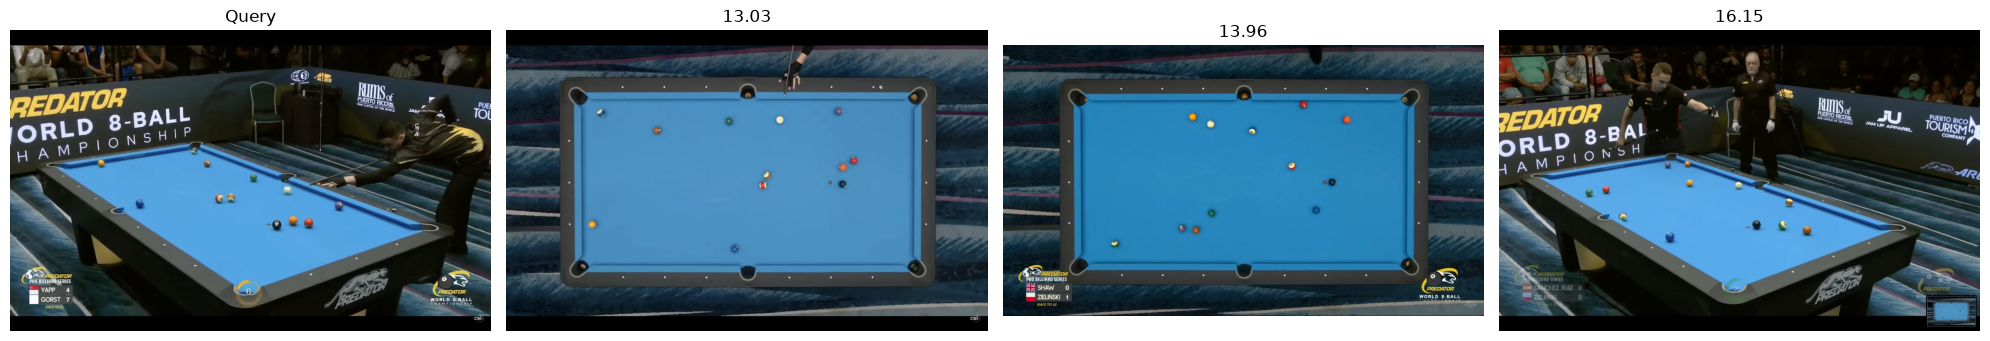

Query image: 4t_png.rf.de24767c63cfdd43e998b62fa3c37be8.jpg


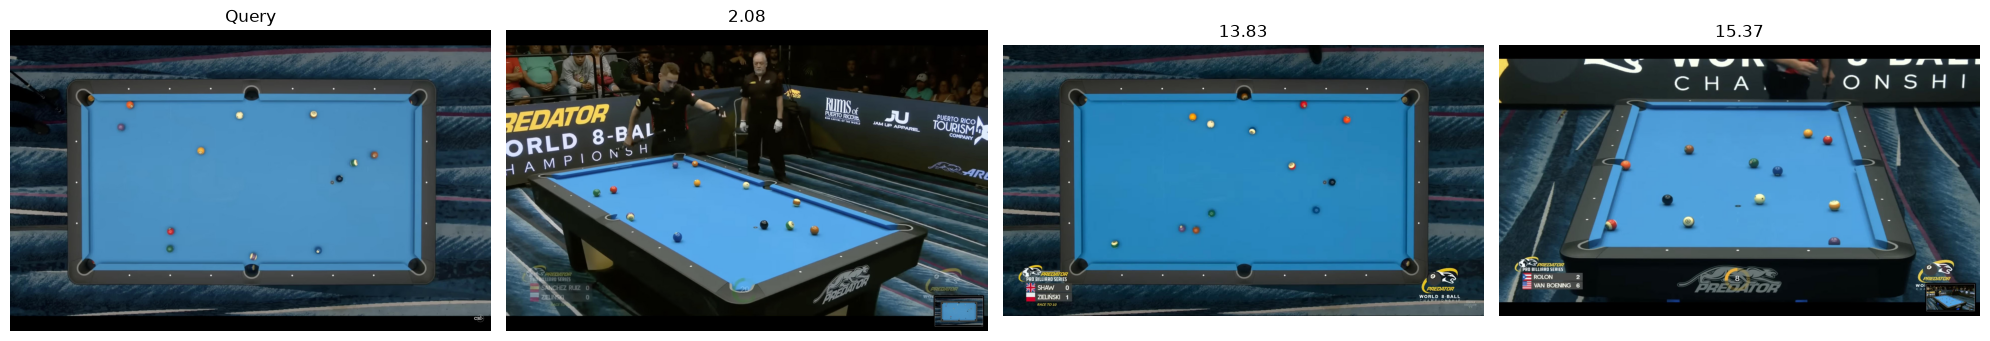

Query image: 7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg


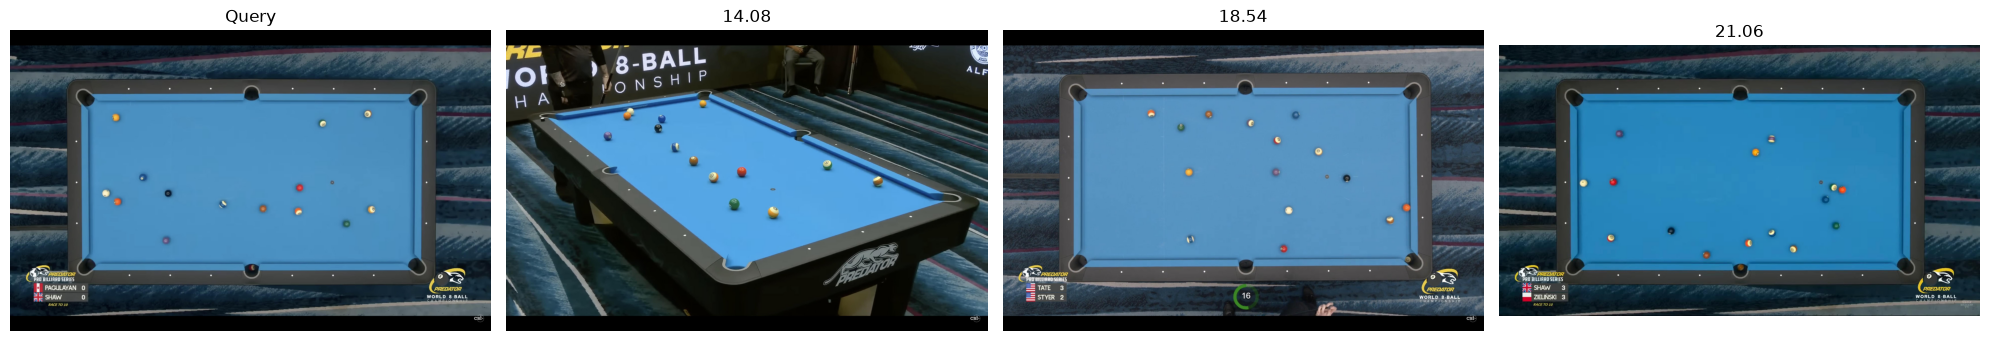

Query image: 21f_png.rf.1d0b1d461f995224e4dda334c1e6a20c.jpg


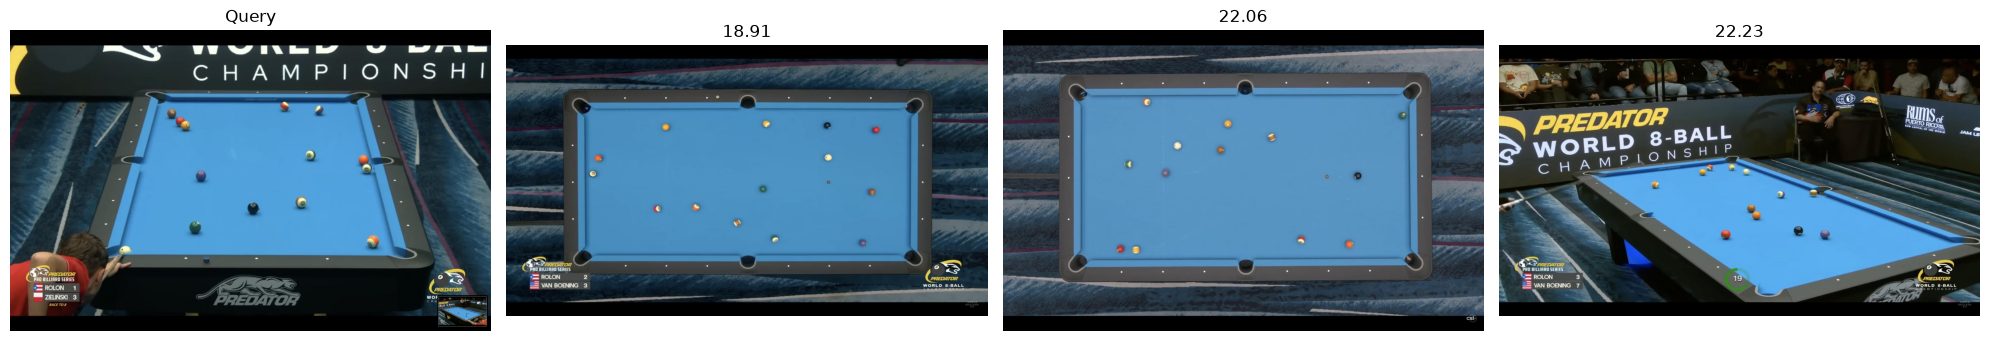

Query image: 24f_png.rf.ee5f961ec533993bb9907fa09380d92a.jpg


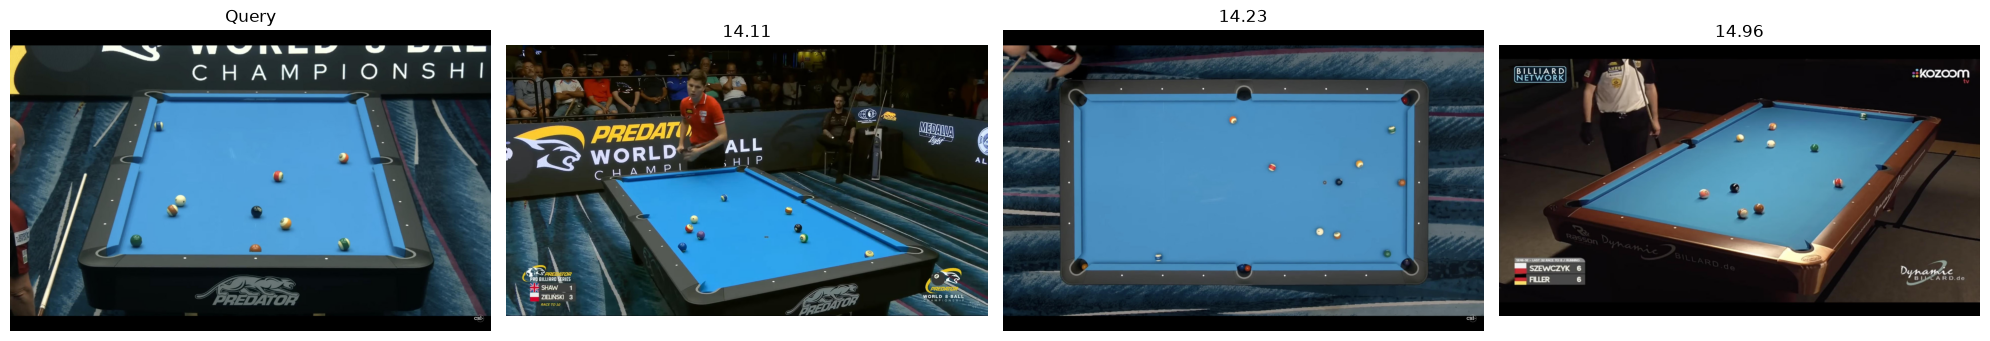

In [110]:
images = [
    "1a_png.rf.17bf9820312efff2213b1d1b08ffad66.jpg",
    "4t_png.rf.de24767c63cfdd43e998b62fa3c37be8.jpg",
    "7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg",
    "21f_png.rf.1d0b1d461f995224e4dda334c1e6a20c.jpg",
    "24f_png.rf.ee5f961ec533993bb9907fa09380d92a.jpg",    
]

for img in images:
    print(f"Query image: {img}")
    similar_tables(img)

